## Try 10.7.1: Principal components with the travel ratings dataset.

**The Python code below imports the travel ratings dataset, calculates a correlation matrix, and applies principal components analysis.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**

In [29]:
# Import packages and data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
reviews = pd.read_csv('tripadvisor_review.csv').dropna()

In [32]:
# Drop user ratings
X = reviews.drop(axis=1, labels='User ID')
X

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
0,0.93,1.80,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,1.02,2.20,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,1.22,0.80,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,0.45,1.80,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,0.51,1.20,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54
...,...,...,...,...,...,...,...,...,...,...
975,0.74,1.12,0.30,0.53,0.88,1.38,3.17,2.78,0.99,3.20
976,1.25,0.92,1.12,0.38,0.78,1.68,3.18,2.79,1.34,2.80
977,0.61,1.32,0.67,0.43,1.30,1.78,3.17,2.81,1.34,3.02
978,0.93,0.20,0.13,0.43,0.30,0.40,3.18,2.98,1.12,2.46


In [33]:
# Standardize input features to mean=0 and sd=1
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=[
        'Art',
        'Clubs',
        'Juice bars',
        'Restaurants',
        'Museums',
        'Resorts',
        'Parks',
        'Beaches',
        'Theaters',
        'Religious',
    ],
)
X.describe().round(2)

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
count,980.00,980.00,980.00,980.00,980.00,980.00,980.00,980.00,980.00,980.00
mean,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.69,-2.83,-1.12,-1.37,-2.01,-3.16,-2.68,-3.02,-2.28,-2.05
25%,-0.68,-0.57,-0.94,-0.44,-0.69,-0.71,-0.12,-0.69,-0.71,-0.81
50%,-0.19,-0.15,-0.25,-0.12,-0.09,-0.08,-0.12,-0.11,-0.08,-0.06
75%,0.39,0.43,0.71,0.17,0.60,0.66,-0.12,0.55,0.52,0.75
max,7.12,4.78,3.31,10.40,5.40,3.56,3.72,4.04,4.39,2.68


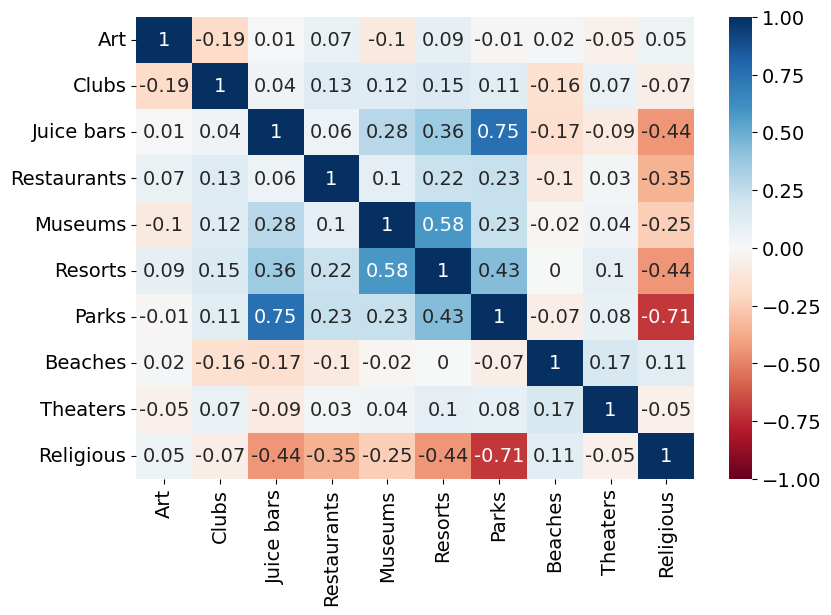

In [34]:
# Plot correlation matrix for input features
plt.figure(figsize=(9, 6))
plt.rcParams.update({'font.size': 14})
sns.heatmap(X.corr().round(2), cmap="RdBu", annot=True, vmin=-1, vmax=1)
plt.show()

## Try 10.7.2: Clustering with the travel ratings dataset.

**The Python code below imports the travel ratings dataset and applies k-means clustering to the dataset.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**

In [35]:
from sklearn.cluster import KMeans

In [36]:
# seed for reproducibility
seed = 123

In [37]:
X

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
0,0.112645,0.935887,1.619750,0.312960,-0.319608,1.070169,1.158657,-0.327872,0.687518,-1.180591
1,0.388088,1.772644,2.089171,0.384494,1.098486,2.479500,3.716053,-1.492056,0.797274,-1.491908
2,1.000186,-1.156005,-0.600487,-0.008942,-1.600466,-0.561689,-0.120041,-0.255111,-0.711877,-0.931537
3,-1.356389,0.935887,-0.917663,0.134126,-1.097272,-0.598777,-0.120041,0.909073,0.001540,0.189205
4,-1.172760,-0.319248,0.211486,0.134126,1.372955,0.328415,-0.120041,-0.400634,-1.068585,-0.807010
...,...,...,...,...,...,...,...,...,...,...
975,-0.468848,-0.486600,-0.904976,-0.008942,-0.136628,-0.858390,-1.398739,-0.400634,-1.589928,1.247683
976,1.092000,-0.904978,0.135363,-0.545444,-0.365353,-0.302075,-0.120041,-0.327872,-0.629559,0.002414
977,-0.866711,-0.068221,-0.435555,-0.366610,0.824016,-0.116637,-1.398739,-0.182349,-0.629559,0.687312
978,0.112645,-2.411141,-1.120656,-0.366610,-1.463232,-2.675687,-0.120041,1.054596,-1.233220,-1.056064


In [38]:
# Initialize a k-means model with k=4
kmModel = KMeans(n_clusters=4, random_state=seed, n_init=10)
kmModel = kmModel.fit(X)
clusters = kmModel.fit_predict(X)
centroids = kmModel.cluster_centers_

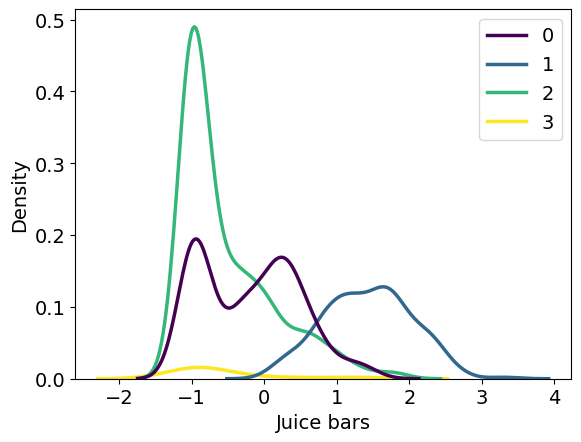

In [39]:
# Show cluster ratings for juice bars
p = sns.kdeplot(data=X, x='Juice bars', hue=clusters, palette='viridis', linewidth=2.5)
p.set_xlabel('Juice bars', fontsize=14)
p.set_ylabel('Density', fontsize=14)
plt.show()

In [40]:
# Describe cluster ratings for juice bars
X[['Juice bars']].groupby(by=clusters).describe().round(2)

Juice bars                                          
       count  mean   std   min   25%   50%   75%   max
0      306.0 -0.20  0.67 -1.11 -0.92 -0.19  0.30  1.49
1      213.0  1.43  0.60  0.10  0.99  1.45  1.84  3.31
2      440.0 -0.53  0.64 -1.12 -1.01 -0.83 -0.19  1.86
3       21.0 -0.58  0.72 -1.12 -1.01 -0.94 -0.55  1.35

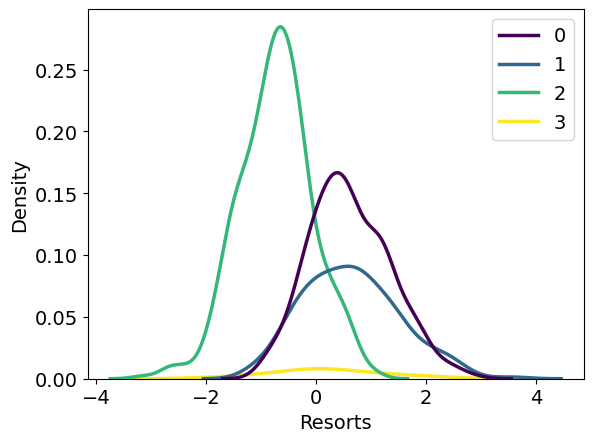

In [41]:
# Show cluster ratings for resorts
p = sns.kdeplot(data=X, x='Resorts', hue=clusters, palette='viridis', linewidth=2.5)
p.set_xlabel('Resorts', fontsize=14)
p.set_ylabel('Density', fontsize=14)
plt.show()

In [42]:
# Describe cluster ratings for juice bars
X[['Resorts']].groupby(by=clusters).describe().round(2)

Resorts                                          
    count  mean   std   min   25%   50%   75%   max
0   306.0  0.61  0.73 -1.01  0.08  0.55  1.14  2.85
1   213.0  0.63  0.88 -1.16 -0.04  0.59  1.22  3.56
2   440.0 -0.74  0.67 -3.16 -1.16 -0.71 -0.34  1.07
3    21.0  0.19  0.99 -1.82 -0.41  0.11  1.03  2.03

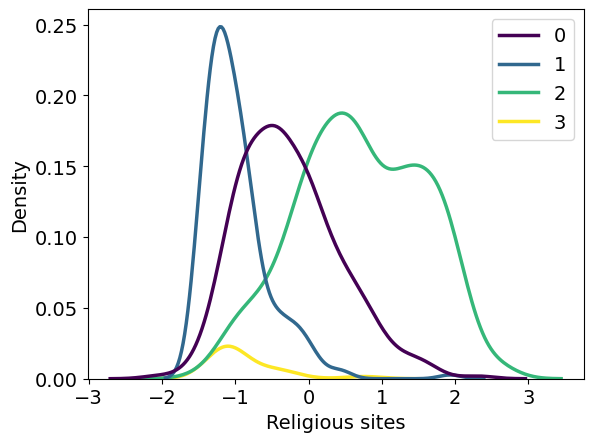

In [43]:
# Show cluster ratings for religious sites
p = sns.kdeplot(data=X, x='Religious', hue=clusters, palette='viridis', linewidth=2.5)
p.set_xlabel('Religious sites', fontsize=14)
p.set_ylabel('Density', fontsize=14)
plt.show()

In [44]:
# Describe cluster ratings for religious sites
X[['Religious']].groupby(by=clusters).describe().round(2)

Religious                                          
      count  mean   std   min   25%   50%   75%   max
0     306.0 -0.27  0.68 -2.05 -0.81 -0.37  0.19  2.31
1     213.0 -0.98  0.45 -1.49 -1.24 -1.06 -0.81  1.93
2     440.0  0.70  0.86 -1.55  0.06  0.69  1.43  2.68
3      21.0 -0.88  0.48 -1.31 -1.18 -1.06 -0.81  0.75

## Try 10.7.3: Outlier detection with the travel ratings dataset.

**The Python code below imports the travel ratings dataset and applies the DBSCAN algorithm for outlier detection.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**

In [45]:
from sklearn.cluster import DBSCAN

In [46]:
X

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
0,0.112645,0.935887,1.619750,0.312960,-0.319608,1.070169,1.158657,-0.327872,0.687518,-1.180591
1,0.388088,1.772644,2.089171,0.384494,1.098486,2.479500,3.716053,-1.492056,0.797274,-1.491908
2,1.000186,-1.156005,-0.600487,-0.008942,-1.600466,-0.561689,-0.120041,-0.255111,-0.711877,-0.931537
3,-1.356389,0.935887,-0.917663,0.134126,-1.097272,-0.598777,-0.120041,0.909073,0.001540,0.189205
4,-1.172760,-0.319248,0.211486,0.134126,1.372955,0.328415,-0.120041,-0.400634,-1.068585,-0.807010
...,...,...,...,...,...,...,...,...,...,...
975,-0.468848,-0.486600,-0.904976,-0.008942,-0.136628,-0.858390,-1.398739,-0.400634,-1.589928,1.247683
976,1.092000,-0.904978,0.135363,-0.545444,-0.365353,-0.302075,-0.120041,-0.327872,-0.629559,0.002414
977,-0.866711,-0.068221,-0.435555,-0.366610,0.824016,-0.116637,-1.398739,-0.182349,-0.629559,0.687312
978,0.112645,-2.411141,-1.120656,-0.366610,-1.463232,-2.675687,-0.120041,1.054596,-1.233220,-1.056064


In [47]:
# Define DBSCAN model
dbscanModel = DBSCAN(eps=1, min_samples=20)

# Fit the model
dbscanModel = dbscanModel.fit(X)
clusters = dbscanModel.fit_predict(X)

In [48]:
# Subset of outliers
outliers = X[clusters == -1]
outliers.describe()

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
count,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02
mean,-2.718914e-17,5.437827e-17,-8.972415e-17,5.147810e-16,-4.440892e-17,1.640411e-16,-1.944476e-14,-1.500840e-15,-2.356392e-16,-9.153676e-16
std,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00,1.000511e+00
min,-1.693043e+00,-2.829519e+00,-1.120656e+00,-1.368082e+00,-2.012171e+00,-3.157826e+00,-2.677437e+00,-3.020048e+00,-2.275906e+00,-2.052279e+00
25%,-6.830819e-01,-5.702755e-01,-9.430372e-01,-4.381438e-01,-6.855674e-01,-7.100398e-01,-1.200410e-01,-6.916798e-01,-7.118768e-01,-8.070103e-01
50%,-1.934040e-01,-1.518970e-01,-2.452487e-01,-1.162422e-01,-9.088308e-02,-7.954928e-02,-1.200410e-01,-1.095877e-01,-8.077737e-02,-5.984914e-02
75%,3.880885e-01,4.338329e-01,7.094529e-01,1.698925e-01,5.952912e-01,6.622042e-01,-1.200410e-01,5.452658e-01,5.228829e-01,7.495755e-01
max,7.121160e+00,4.784969e+00,3.307129e+00,1.039921e+01,5.398511e+00,3.555043e+00,3.716053e+00,4.037818e+00,4.391797e+00,2.679742e+00


In [49]:
# Subset of non-outliers
nonoutliers = X[clusters == 0]
nonoutliers.describe()

,Art,Clubs,Juice bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


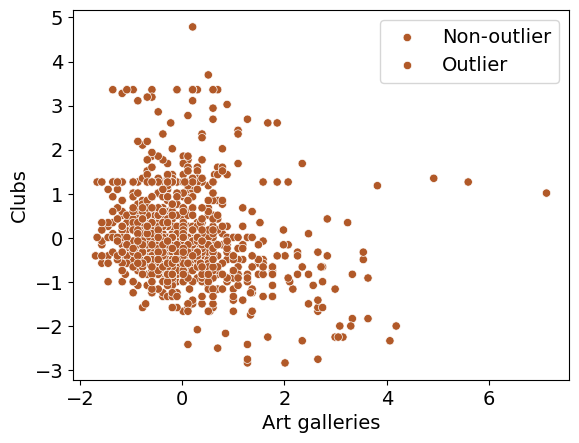

In [50]:
# Plot art gallery and club ratings
p = sns.scatterplot(
    data=X, x='Art', y='Clubs', hue=clusters, style=clusters, palette='Paired_r'
)
p.set_xlabel('Art galleries', fontsize=14)
p.set_ylabel('Clubs', fontsize=14)
plt.legend(labels=['Non-outlier', 'Outlier'])
plt.show()

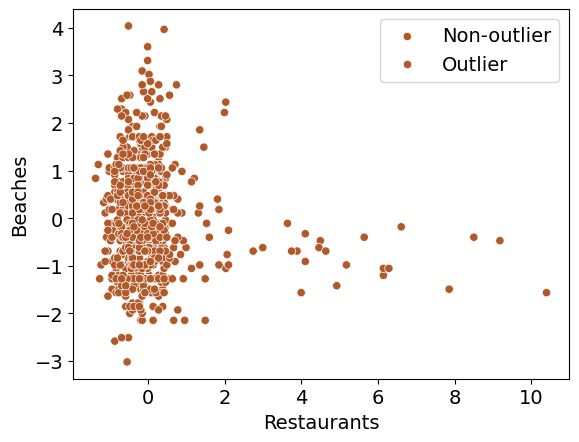

In [51]:
# Plot restaurant and beach ratings
p = sns.scatterplot(
    data=X,
    x='Restaurants',
    y='Beaches',
    hue=clusters,
    style=clusters,
    palette='Paired_r',
)
p.set_xlabel('Restaurants', fontsize=14)
p.set_ylabel('Beaches', fontsize=14)
plt.legend(labels=['Non-outlier', 'Outlier'])
plt.show()